## Results

### Graphene - BC₃

* Top (shift 0)
  * Most stable Lattice constant: 5.050
  * Most stable distance: 3.432
  * Minimal free energy: -142.273
  * B-C bond:
  * C-C bond:

* Bridge (shift 1/12)
  * Most stable Lattice constant:
  * Most stable distance:
  * Minimal free energy:
  * B-C bond:
  * C-C bond:

* Hollow (shift 1/6)
  * Most stable Lattice constant:
  * Most stable distance:
  * Minimal free energy:
  * B-C bond:
  * C-C bond:

### Graphene - Borophene

* Top  (shift 0)
  * Most stable Lattice constant:
  * Most stable distance:
  * Minimal free energy:
  * B-C bond:
  * C-C bond:

* Bridge  (shift 1/12)
  * Most stable Lattice constant:
  * Most stable distance:
  * Minimal free energy:
  * B-C bond:
  * C-C bond:

* Hollow_1  (shift 1/9)
  * Most stable Lattice constant:
  * Most stable distance:
  * Minimal free energy:
  * B-C bond:
  * C-C bond:

* Hollow_2  (shift 1/6)
  * Most stable Lattice constant:
  * Most stable distance:
  * Minimal free energy:
  * B-C bond:
  * C-C bond:

### Graphene - B₄C₃

* Top (shift -1/6)
  * Most stable Lattice constant:
  * Most stable distance:
  * Minimal free energy:
  * B-C bond:
  * C-C bond:

* Bridge (shift -1/12)
  * Most stable Lattice constant:
  * Most stable distance:
  * Minimal free energy:
  * B-C bond:
  * C-C bond:

* Hollow_1 (shift -1/18)
  * Most stable Lattice constant:
  * Most stable distance:
  * Minimal free energy:
  * B-C bond:
  * C-C bond:

* Hollow_2 (shift 0)
  * Most stable Lattice constant:
  * Most stable distance:
  * Minimal free energy:
  * B-C bond:
  * C-C bond:


Fitted extrema lattice of Top: 5.044105963794048(Å), the corresponding energy is -142.27488080183866(eV).
Fitted extrema lattice of Bridge: 5.044106838547547(Å), the corresponding energy is -142.2901117511774(eV).
Fitted extrema lattice of Hollow: 5.0442078842183316(Å), the corresponding energy is -142.29252465827676(eV).


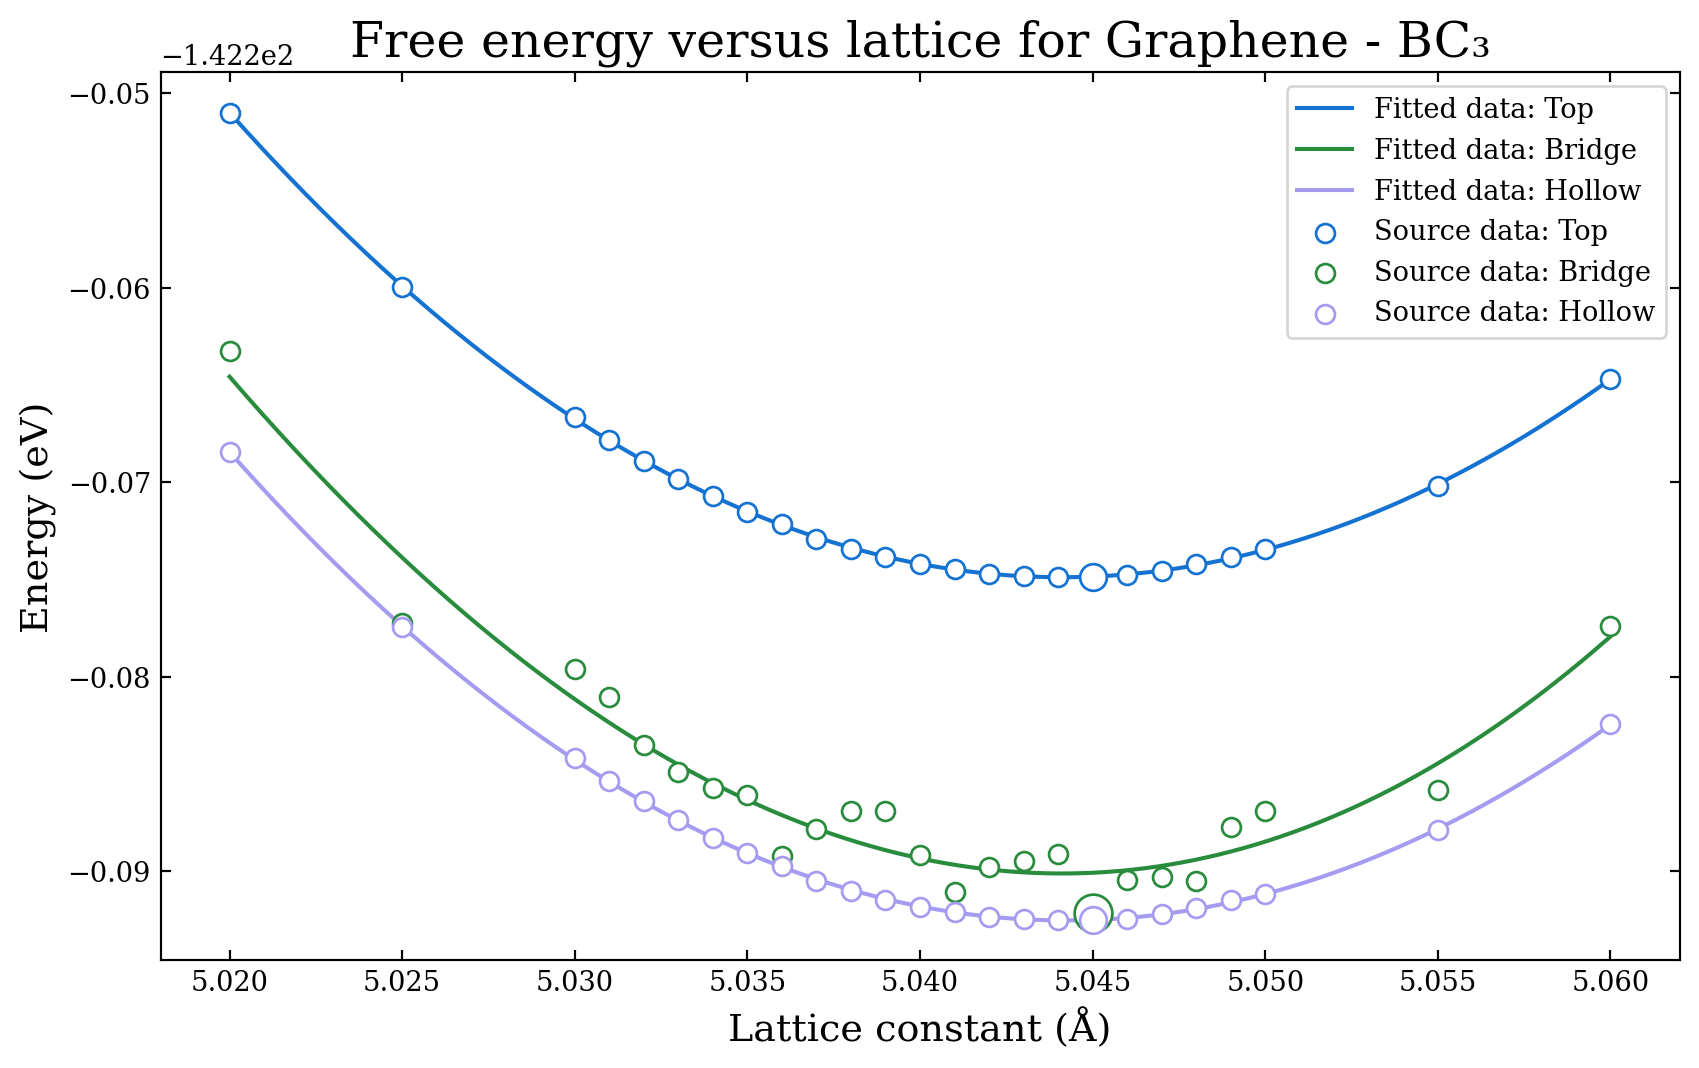

In [10]:
#### Graphene - BC3

## Read data
import numpy as np
from Store.lattice_extracting import read_lattice_distance, read_lattice_distance_select
from Store.lattice_selecting import lattice_select
from Store.filter_segment import filter_segment

Matter = "Graphene - BC₃"

## Lattice range
lattice_start = 5.020
lattice_end = 5.060

## Source data
# Top
lattice_Top_source, distance_Top_source, energy_Top_source = read_lattice_distance("0_Lattice_Twin_Lattice/A1_Graphene-BC3_Top/lattice.dat")
# Bridge
lattice_Bridge_source, distance_Bridge_source, energy_Bridge_source = read_lattice_distance("0_Lattice_Twin_Lattice/A2_Graphene-BC3_Bridge/lattice.dat")
# Hollow
lattice_Hollow_source, distance_Hollow_source, energy_Hollow_source = read_lattice_distance("0_Lattice_Twin_Lattice/A3_Graphene-BC3_Hollow/lattice.dat")

## Discretized source data
divisor = 1
# Top
lattice_Top_dis, distance_Top_dis, energy_Top_dis = read_lattice_distance_select("0_Lattice_Twin_Lattice/A1_Graphene-BC3_Top/lattice.dat",1000,divisor)
# Bridge
lattice_Bridge_dis, distance_Bridge_dis, energy_Bridge_dis = read_lattice_distance_select("0_Lattice_Twin_Lattice/A2_Graphene-BC3_Bridge/lattice.dat",1000,divisor)
# Hollow
lattice_Hollow_dis, distance_Hollow_dis, energy_Hollow_dis = read_lattice_distance_select("0_Lattice_Twin_Lattice/A3_Graphene-BC3_Hollow/lattice.dat",1000,divisor)

## Segment select
lattice_Top, distance_Top, energy_Top = filter_segment(lattice_Top_dis, distance_Top_dis, energy_Top_dis, lattice_start, lattice_end)
lattice_Bridge, distance_Bridge, energy_Bridge = filter_segment(lattice_Bridge_dis, distance_Bridge_dis, energy_Bridge_dis, lattice_start, lattice_end)
lattice_Hollow, distance_Hollow, energy_Hollow = filter_segment(lattice_Hollow_dis, distance_Hollow_dis, energy_Hollow_dis, lattice_start, lattice_end)

# Lattice range
lattice_range = max(max(lattice_Top), max(lattice_Bridge), max(lattice_Hollow))-min(min(lattice_Top), min(lattice_Bridge), min(lattice_Hollow))
# Energy range
energy_max = max(max(energy_Top), max(energy_Bridge), max(energy_Hollow))
energy_min = min(min(energy_Top), min(energy_Bridge), min(energy_Hollow))
energy_range = energy_max - energy_min

## Fit curve
# Top
p_Top = np.polyfit(lattice_Top, energy_Top, 3)
f_Top = np.poly1d(p_Top)
lattice_Top_fitted = np.linspace(min(lattice_Top), max(lattice_Top), num=1000, endpoint=True)
energy_Top_fitted = f_Top(lattice_Top_fitted)
# Bridge
p_Bridge = np.polyfit(lattice_Bridge, energy_Bridge, 3)
f_Bridge  = np.poly1d(p_Bridge)
lattice_Bridge_fitted = np.linspace(min(lattice_Bridge), max(lattice_Bridge), num=1000, endpoint=True)
energy_Bridge_fitted = f_Bridge(lattice_Bridge_fitted)
# Hollow
p_Hollow = np.polyfit(lattice_Hollow, energy_Hollow, 3)
f_Hollow  = np.poly1d(p_Hollow)
lattice_Hollow_fitted = np.linspace(min(lattice_Hollow), max(lattice_Hollow), num=1000, endpoint=True)
energy_Hollow_fitted = f_Hollow(lattice_Hollow_fitted)

## Extrema point of source data
# Top
energy_Top_min = np.min(energy_Top_source)
lattice_Top_min = lattice_Top_source[np.argmin(energy_Top_source)]
# Bridge
energy_Bridge_min = np.min(energy_Bridge_source)
lattice_Bridge_min = lattice_Bridge_source[np.argmin(energy_Bridge_source)]
# Hollow
energy_Hollow_min = np.min(energy_Hollow_source)
lattice_Hollow_min = lattice_Hollow_source[np.argmin(energy_Hollow_source)]

## Extrema point of fitted data
# Top
f_Top_prime = f_Top.deriv()
roots_Top = f_Top_prime.r
fitted_lattice_Top_extrema = roots_Top[(roots_Top >= min(lattice_Top)) & (roots_Top <= max(lattice_Top))]
fitted_energy_Top_extrema = f_Top(fitted_lattice_Top_extrema)
fitted_energy_Top_min = np.min(fitted_energy_Top_extrema)
fitted_lattice_Top_min = fitted_lattice_Top_extrema[np.argmin(fitted_energy_Top_min)]
# Bridge
f_Bridge_prime = f_Bridge.deriv()
roots_Bridge = f_Bridge_prime.r
fitted_lattice_Bridge_extrema = roots_Bridge[(roots_Bridge >= min(lattice_Bridge)) & (roots_Bridge <= max(lattice_Bridge))]
fitted_energy_Bridge_extrema = f_Bridge(fitted_lattice_Bridge_extrema)
fitted_energy_Bridge_min = np.min(fitted_energy_Bridge_extrema)
fitted_lattice_Bridge_min = fitted_lattice_Bridge_extrema[np.argmin(fitted_energy_Bridge_min)]
# Hollow
f_Hollow_prime = f_Hollow.deriv()
roots_Hollow = f_Hollow_prime.r
fitted_lattice_Hollow_extrema = roots_Hollow[(roots_Hollow >= min(lattice_Hollow)) & (roots_Hollow <= max(lattice_Hollow))]
fitted_energy_Hollow_extrema = f_Hollow(fitted_lattice_Hollow_extrema)
fitted_energy_Hollow_min = np.min(fitted_energy_Hollow_extrema)
fitted_lattice_Hollow_min = fitted_lattice_Hollow_extrema[np.argmin(fitted_energy_Hollow_min)]

print(f"Fitted extrema lattice of Top: {np.float(fitted_lattice_Top_min)}(Å), the corresponding energy is {np.float(fitted_energy_Top_min)}(eV).")
print(f"Fitted extrema lattice of Bridge: {np.float(fitted_lattice_Bridge_min)}(Å), the corresponding energy is {np.float(fitted_energy_Bridge_min)}(eV).")
print(f"Fitted extrema lattice of Hollow: {np.float(fitted_lattice_Hollow_min)}(Å), the corresponding energy is {np.float(fitted_energy_Hollow_min)}(eV).")

## Plot
import matplotlib.pyplot as plt

plt.figure(dpi=196, figsize=(10,6))
params = {"text.usetex": False, "font.family": "serif", "mathtext.fontset": "cm",
          "axes.titlesize": 18, "axes.labelsize": 14, "figure.facecolor": "w"}
plt.rcParams.update(params)
plt.tick_params(direction="in", which="both", top=True, right=True, bottom=True, left=True)
plt.title(f"Free energy versus lattice for {Matter}"); plt.xlabel(r"Lattice constant (Å)"); plt.ylabel(r"Energy (eV)")

# Source data: Top
plt.scatter(lattice_Top, energy_Top, s=48, facecolors="#FFFFFF", edgecolors="#1473D2", label="Source data: Top", zorder=2)
plt.scatter(lattice_Top_min, energy_Top_min, s=96, facecolors="#FFFFFF", edgecolors="#1473D2", zorder=2)
# Source data: Bridge
plt.scatter(lattice_Bridge, energy_Bridge, s=48, facecolors="#FFFFFF", edgecolors="#288C3C", label="Source data: Bridge", zorder=2)
plt.scatter(lattice_Bridge_min, energy_Bridge_min, s=192, facecolors="#FFFFFF", edgecolors="#288C3C", zorder=2)
# Source data: Hollow
plt.scatter(lattice_Hollow, energy_Hollow, s=48, facecolors="#FFFFFF", edgecolors="#A59BF0", label="Source data: Hollow", zorder=2)
plt.scatter(lattice_Hollow_min, energy_Hollow_min, s=96, facecolors="#FFFFFF", edgecolors="#A59BF0", zorder=2)

# Fitted data: top
plt.plot(lattice_Top_fitted, energy_Top_fitted, color="#1473D2", label="Fitted data: Top", zorder=1)
# Fitted data: Bridge
plt.plot(lattice_Bridge_fitted, energy_Bridge_fitted, color="#288C3C", label="Fitted data: Bridge", zorder=1)
# Fitted data: Hollow
plt.plot(lattice_Hollow_fitted, energy_Hollow_fitted, color="#A59BF0", label="Fitted data: Hollow", zorder=1)

plt.ylim(energy_min-energy_range*0.05,energy_max+energy_range*0.05)
plt.legend(loc="upper right")


Fitted extrema lattice of Top: 4.978901295643808(Å), the corresponding energy is -125.92746574569173(eV).
Fitted extrema lattice of Bridge: 4.97847280143646(Å), the corresponding energy is -125.91742451506252(eV).
Fitted extrema lattice of Hollow 1: 4.978660088277128(Å), the corresponding energy is -125.9123909429909(eV).
Fitted extrema lattice of Hollow 2: 4.980102250064881(Å), the corresponding energy is -125.90933262751969(eV).


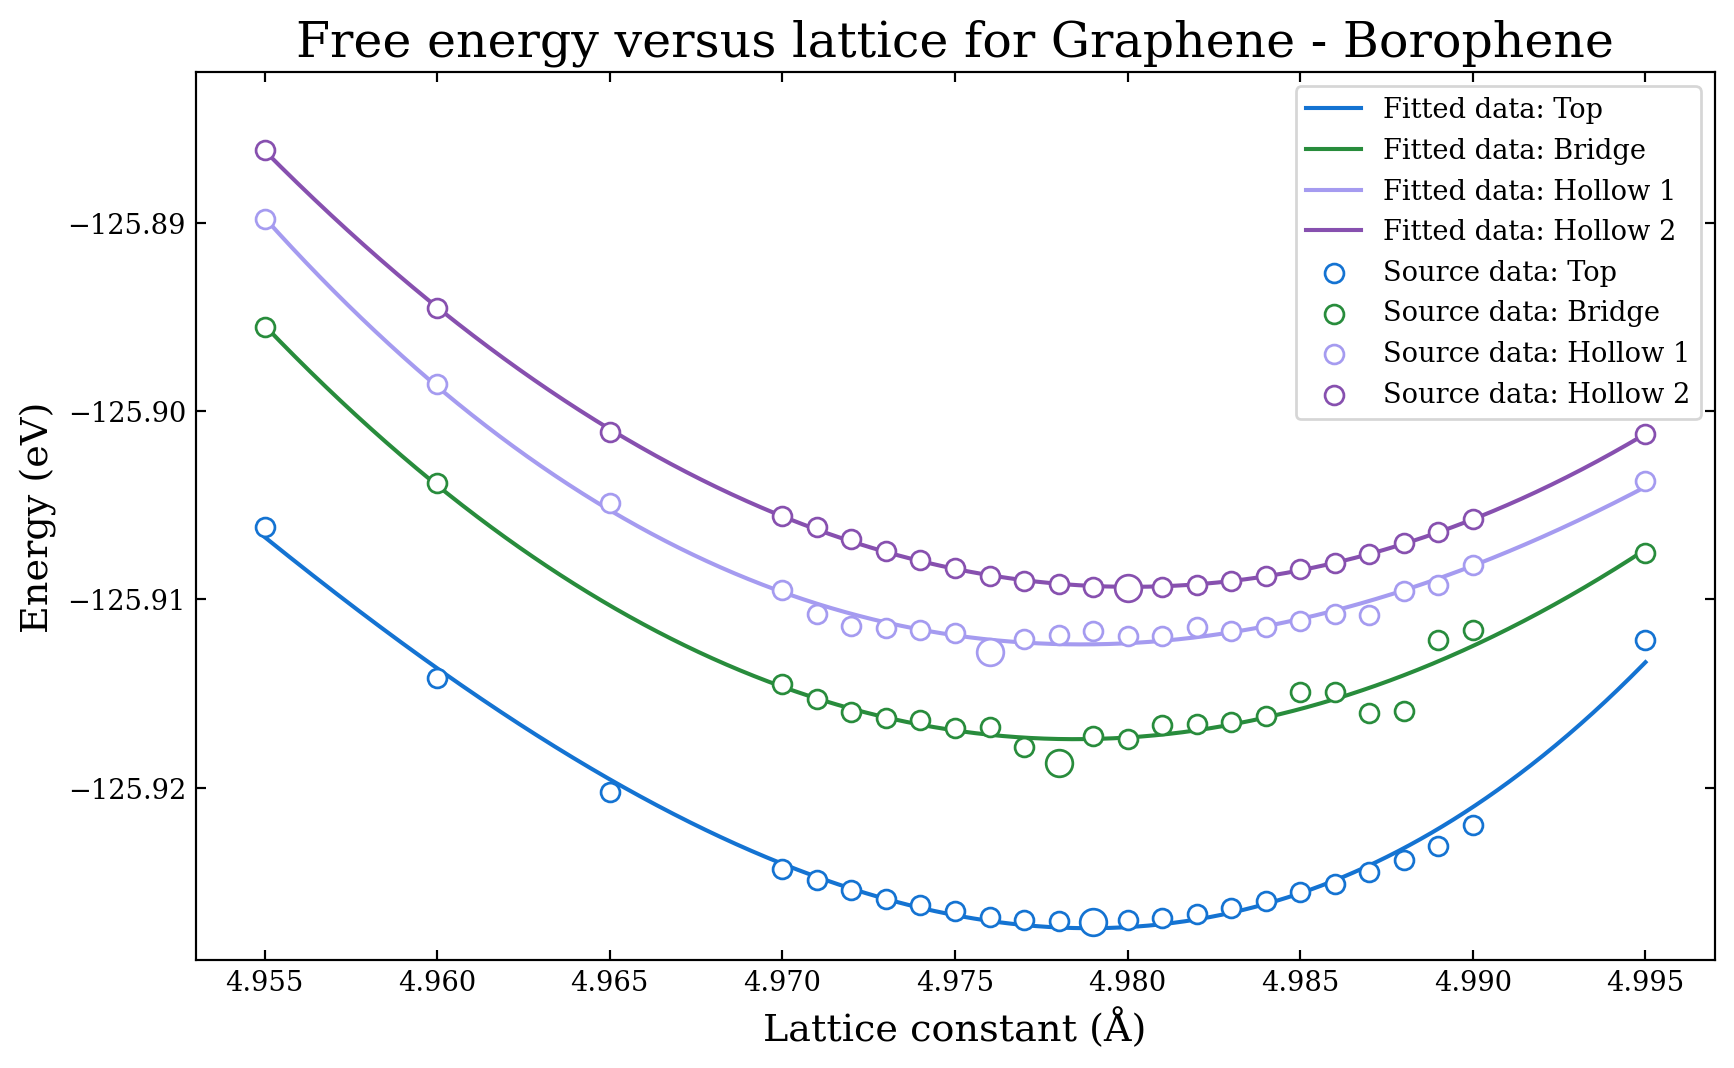

In [8]:
#### Graphene - Borophene

## Read data
import numpy as np
from Store.lattice_extracting import read_lattice_distance
from Store.lattice_selecting import lattice_select
from Store.filter_segment import filter_segment

Matter = "Graphene - Borophene"

## Lattice range
lattice_start = 4.955
lattice_end = 4.995

## Source data
# Top
lattice_Top_source, distance_Top_source, energy_Top_source = read_lattice_distance("0_Lattice_Twin_Lattice/B1_Graphene-Borophene_Top/lattice.dat")
# Bridge
lattice_Bridge_source, distance_Bridge_source, energy_Bridge_source = read_lattice_distance("0_Lattice_Twin_Lattice/B2_Graphene-Borophene_Bridge/lattice.dat")
# Hollow 1
lattice_Hollow_1_source, distance_Hollow_1_source, energy_Hollow_1_source = read_lattice_distance("0_Lattice_Twin_Lattice/B3_Graphene-Borophene_Hollow_1/lattice.dat")
# Hollow 2
lattice_Hollow_2_source, distance_Hollow_2_source, energy_Hollow_2_source = read_lattice_distance("0_Lattice_Twin_Lattice/B4_Graphene-Borophene_Hollow_2/lattice.dat")

## Discretized source data
divisor = 1
# Top
lattice_Top_dis, distance_Top_dis, energy_Top_dis = read_lattice_distance_select("0_Lattice_Twin_Lattice/B1_Graphene-Borophene_Top/lattice.dat",1000,divisor)
# Bridge
lattice_Bridge_dis, distance_Bridge_dis, energy_Bridge_dis = read_lattice_distance_select("0_Lattice_Twin_Lattice/B2_Graphene-Borophene_Bridge/lattice.dat",1000,divisor)
# Hollow 1
lattice_Hollow_1_dis, distance_Hollow_1_dis, energy_Hollow_1_dis = read_lattice_distance_select("0_Lattice_Twin_Lattice/B3_Graphene-Borophene_Hollow_1/lattice.dat",1000,divisor)
# Hollow 2
lattice_Hollow_2_dis, distance_Hollow_2_dis, energy_Hollow_2_dis = read_lattice_distance_select("0_Lattice_Twin_Lattice/B4_Graphene-Borophene_Hollow_2/lattice.dat",1000,divisor)

## Segment select
lattice_Top, distance_Top, energy_Top = filter_segment(lattice_Top_dis, distance_Top_dis, energy_Top_dis, lattice_start, lattice_end)
lattice_Bridge, distance_Bridge, energy_Bridge = filter_segment(lattice_Bridge_dis, distance_Bridge_dis, energy_Bridge_dis, lattice_start, lattice_end)
lattice_Hollow_1, distance_Hollow_1, energy_Hollow_1 = filter_segment(lattice_Hollow_1_dis, distance_Hollow_1_dis, energy_Hollow_1_dis, lattice_start, lattice_end)
lattice_Hollow_2, distance_Hollow_2, energy_Hollow_2 = filter_segment(lattice_Hollow_2_dis, distance_Hollow_2_dis, energy_Hollow_2_dis, lattice_start, lattice_end)

# Lattice range
lattice_range = max(max(lattice_Top), max(lattice_Bridge), max(lattice_Hollow_1), max(lattice_Hollow_2))-min(min(lattice_Top), min(lattice_Bridge), min(lattice_Hollow_1), min(lattice_Hollow_2))
# Energy range
energy_max = max(max(energy_Top), max(energy_Bridge), max(energy_Hollow_1), max(energy_Hollow_2))
energy_min = min(min(energy_Top), min(energy_Bridge), min(energy_Hollow_1), min(energy_Hollow_2))
energy_range = energy_max - energy_min

## Fit curve
# Top
p_Top = np.polyfit(lattice_Top, energy_Top, 3)
f_Top = np.poly1d(p_Top)
lattice_Top_fitted = np.linspace(min(lattice_Top), max(lattice_Top), num=1000, endpoint=True)
energy_Top_fitted = f_Top(lattice_Top_fitted)
# Bridge
p_Bridge = np.polyfit(lattice_Bridge, energy_Bridge, 3)
f_Bridge  = np.poly1d(p_Bridge)
lattice_Bridge_fitted = np.linspace(min(lattice_Bridge), max(lattice_Bridge), num=1000, endpoint=True)
energy_Bridge_fitted = f_Bridge(lattice_Bridge_fitted)
# Hollow 1
p_Hollow_1 = np.polyfit(lattice_Hollow_1, energy_Hollow_1, 3)
f_Hollow_1  = np.poly1d(p_Hollow_1)
lattice_Hollow_1_fitted = np.linspace(min(lattice_Hollow_1), max(lattice_Hollow_1), num=1000, endpoint=True)
energy_Hollow_1_fitted = f_Hollow_1(lattice_Hollow_1_fitted)
# Hollow 2
p_Hollow_2 = np.polyfit(lattice_Hollow_2, energy_Hollow_2, 3)
f_Hollow_2  = np.poly1d(p_Hollow_2)
lattice_Hollow_2_fitted = np.linspace(min(lattice_Hollow_2), max(lattice_Hollow_2), num=1000, endpoint=True)
energy_Hollow_2_fitted = f_Hollow_2(lattice_Hollow_2_fitted)

## Extrema point of source data
# Top
energy_Top_min = np.min(energy_Top_source)
lattice_Top_min = lattice_Top_source[np.argmin(energy_Top_source)]
# Bridge
energy_Bridge_min = np.min(energy_Bridge_source)
lattice_Bridge_min = lattice_Bridge_source[np.argmin(energy_Bridge_source)]
# Hollow_1
energy_Hollow_1_min = np.min(energy_Hollow_1_source)
lattice_Hollow_1_min = lattice_Hollow_1_source[np.argmin(energy_Hollow_1_source)]
# Hollow_2
energy_Hollow_2_min = np.min(energy_Hollow_2_source)
lattice_Hollow_2_min = lattice_Hollow_2_source[np.argmin(energy_Hollow_2_source)]

## Extrema point of fitted data
# Top
f_Top_prime = f_Top.deriv()
roots_Top = f_Top_prime.r
fitted_lattice_Top_extrema = roots_Top[(roots_Top >= min(lattice_Top)) & (roots_Top <= max(lattice_Top))]
fitted_energy_Top_extrema = f_Top(fitted_lattice_Top_extrema)
fitted_energy_Top_min = np.min(fitted_energy_Top_extrema)
fitted_lattice_Top_min = fitted_lattice_Top_extrema[np.argmin(fitted_energy_Top_min)]
# Bridge
f_Bridge_prime = f_Bridge.deriv()
roots_Bridge = f_Bridge_prime.r
fitted_lattice_Bridge_extrema = roots_Bridge[(roots_Bridge >= min(lattice_Bridge)) & (roots_Bridge <= max(lattice_Bridge))]
fitted_energy_Bridge_extrema = f_Bridge(fitted_lattice_Bridge_extrema)
fitted_energy_Bridge_min = np.min(fitted_energy_Bridge_extrema)
fitted_lattice_Bridge_min = fitted_lattice_Bridge_extrema[np.argmin(fitted_energy_Bridge_min)]
# Hollow 1
f_Hollow_1_prime = f_Hollow_1.deriv()
roots_Hollow_1 = f_Hollow_1_prime.r
fitted_lattice_Hollow_1_extrema = roots_Hollow_1[(roots_Hollow_1 >= min(lattice_Hollow_1)) & (roots_Hollow_1 <= max(lattice_Hollow_1))]
fitted_energy_Hollow_1_extrema = f_Hollow_1(fitted_lattice_Hollow_1_extrema)
fitted_energy_Hollow_1_min = np.min(fitted_energy_Hollow_1_extrema)
fitted_lattice_Hollow_1_min = fitted_lattice_Hollow_1_extrema[np.argmin(fitted_energy_Hollow_1_min)]
# Hollow 2
f_Hollow_2_prime = f_Hollow_2.deriv()
roots_Hollow_2 = f_Hollow_2_prime.r
fitted_lattice_Hollow_2_extrema = roots_Hollow_2[(roots_Hollow_2 >= min(lattice_Hollow_2)) & (roots_Hollow_2 <= max(lattice_Hollow_2))]
fitted_energy_Hollow_2_extrema = f_Hollow_2(fitted_lattice_Hollow_2_extrema)
fitted_energy_Hollow_2_min = np.min(fitted_energy_Hollow_2_extrema)
fitted_lattice_Hollow_2_min = fitted_lattice_Hollow_2_extrema[np.argmin(fitted_energy_Hollow_2_min)]

print(f"Fitted extrema lattice of Top: {np.float(fitted_lattice_Top_min)}(Å), the corresponding energy is {np.float(fitted_energy_Top_min)}(eV).")
print(f"Fitted extrema lattice of Bridge: {np.float(fitted_lattice_Bridge_min)}(Å), the corresponding energy is {np.float(fitted_energy_Bridge_min)}(eV).")
print(f"Fitted extrema lattice of Hollow 1: {np.float(fitted_lattice_Hollow_1_min)}(Å), the corresponding energy is {np.float(fitted_energy_Hollow_1_min)}(eV).")
print(f"Fitted extrema lattice of Hollow 2: {np.float(fitted_lattice_Hollow_2_min)}(Å), the corresponding energy is {np.float(fitted_energy_Hollow_2_min)}(eV).")

## Plot
import matplotlib.pyplot as plt

plt.figure(dpi=196, figsize=(10,6))
params = {"text.usetex": False, "font.family": "serif", "mathtext.fontset": "cm",
          "axes.titlesize": 18, "axes.labelsize": 14, "figure.facecolor": "w"}
plt.rcParams.update(params)
plt.tick_params(direction="in", which="both", top=True, right=True, bottom=True, left=True)
plt.title(f"Free energy versus lattice for {Matter}"); plt.xlabel(r"Lattice constant (Å)"); plt.ylabel(r"Energy (eV)")

# Source data: Top
plt.scatter(lattice_Top, energy_Top, s=48, facecolors="#FFFFFF", edgecolors="#1473D2", label="Source data: Top", zorder=2)
plt.scatter(lattice_Top_min, energy_Top_min, s=96, facecolors="#FFFFFF", edgecolors="#1473D2", zorder=2)
# Source data: Bridge
plt.scatter(lattice_Bridge, energy_Bridge, s=48, facecolors="#FFFFFF", edgecolors="#288C3C", label="Source data: Bridge", zorder=2)
plt.scatter(lattice_Bridge_min, energy_Bridge_min, s=96, facecolors="#FFFFFF", edgecolors="#288C3C", zorder=2)
# Source data: Hollow 1
plt.scatter(lattice_Hollow_1, energy_Hollow_1, s=48, facecolors="#FFFFFF", edgecolors="#A59BF0", label="Source data: Hollow 1", zorder=2)
plt.scatter(lattice_Hollow_1_min, energy_Hollow_1_min, s=96, facecolors="#FFFFFF", edgecolors="#A59BF0", zorder=2)
# Source data: Hollow 2
plt.scatter(lattice_Hollow_2, energy_Hollow_2, s=48, facecolors="#FFFFFF", edgecolors="#8750AF", label="Source data: Hollow 2", zorder=2)
plt.scatter(lattice_Hollow_2_min, energy_Hollow_2_min, s=96, facecolors="#FFFFFF", edgecolors="#8750AF", zorder=2)

# Fitted data: top
plt.plot(lattice_Top_fitted, energy_Top_fitted, color="#1473D2", label="Fitted data: Top", zorder=1)
# Fitted data: Bridge
plt.plot(lattice_Bridge_fitted, energy_Bridge_fitted, color="#288C3C", label="Fitted data: Bridge", zorder=1)
# Fitted data: Hollow 1
plt.plot(lattice_Hollow_1_fitted, energy_Hollow_1_fitted, color="#A59BF0", label="Fitted data: Hollow 1", zorder=1)
# Fitted data: Hollow 2
plt.plot(lattice_Hollow_2_fitted, energy_Hollow_2_fitted, color="#8750AF", label="Fitted data: Hollow 2", zorder=1)

plt.ylim(energy_min-energy_range*0.05,energy_max+energy_range*0.1)
plt.legend(loc="upper right")

Fitted extrema lattice of Top: 4.845704785680618(Å), the corresponding energy is -127.13809499377908(eV).
Fitted extrema lattice of Bridge: 4.847331173788902(Å), the corresponding energy is -127.13600054702692(eV).
Fitted extrema lattice of Hollow 1: 4.844854431362277(Å), the corresponding energy is -127.14257745444775(eV).
Fitted extrema lattice of Hollow 2: 4.845624843409778(Å), the corresponding energy is -127.12440766441341(eV).


/home/562/ln2626/.local/lib/python3.6/site-packages/IPython/core/interactiveshell.py:3343: RankWarning: Polyfit may be poorly conditioned
  exec(code_obj, self.user_global_ns, self.user_ns)
/home/562/ln2626/.local/lib/python3.6/site-packages/ipykernel_launcher.py:117: ComplexWarning: Casting complex values to real discards the imaginary part


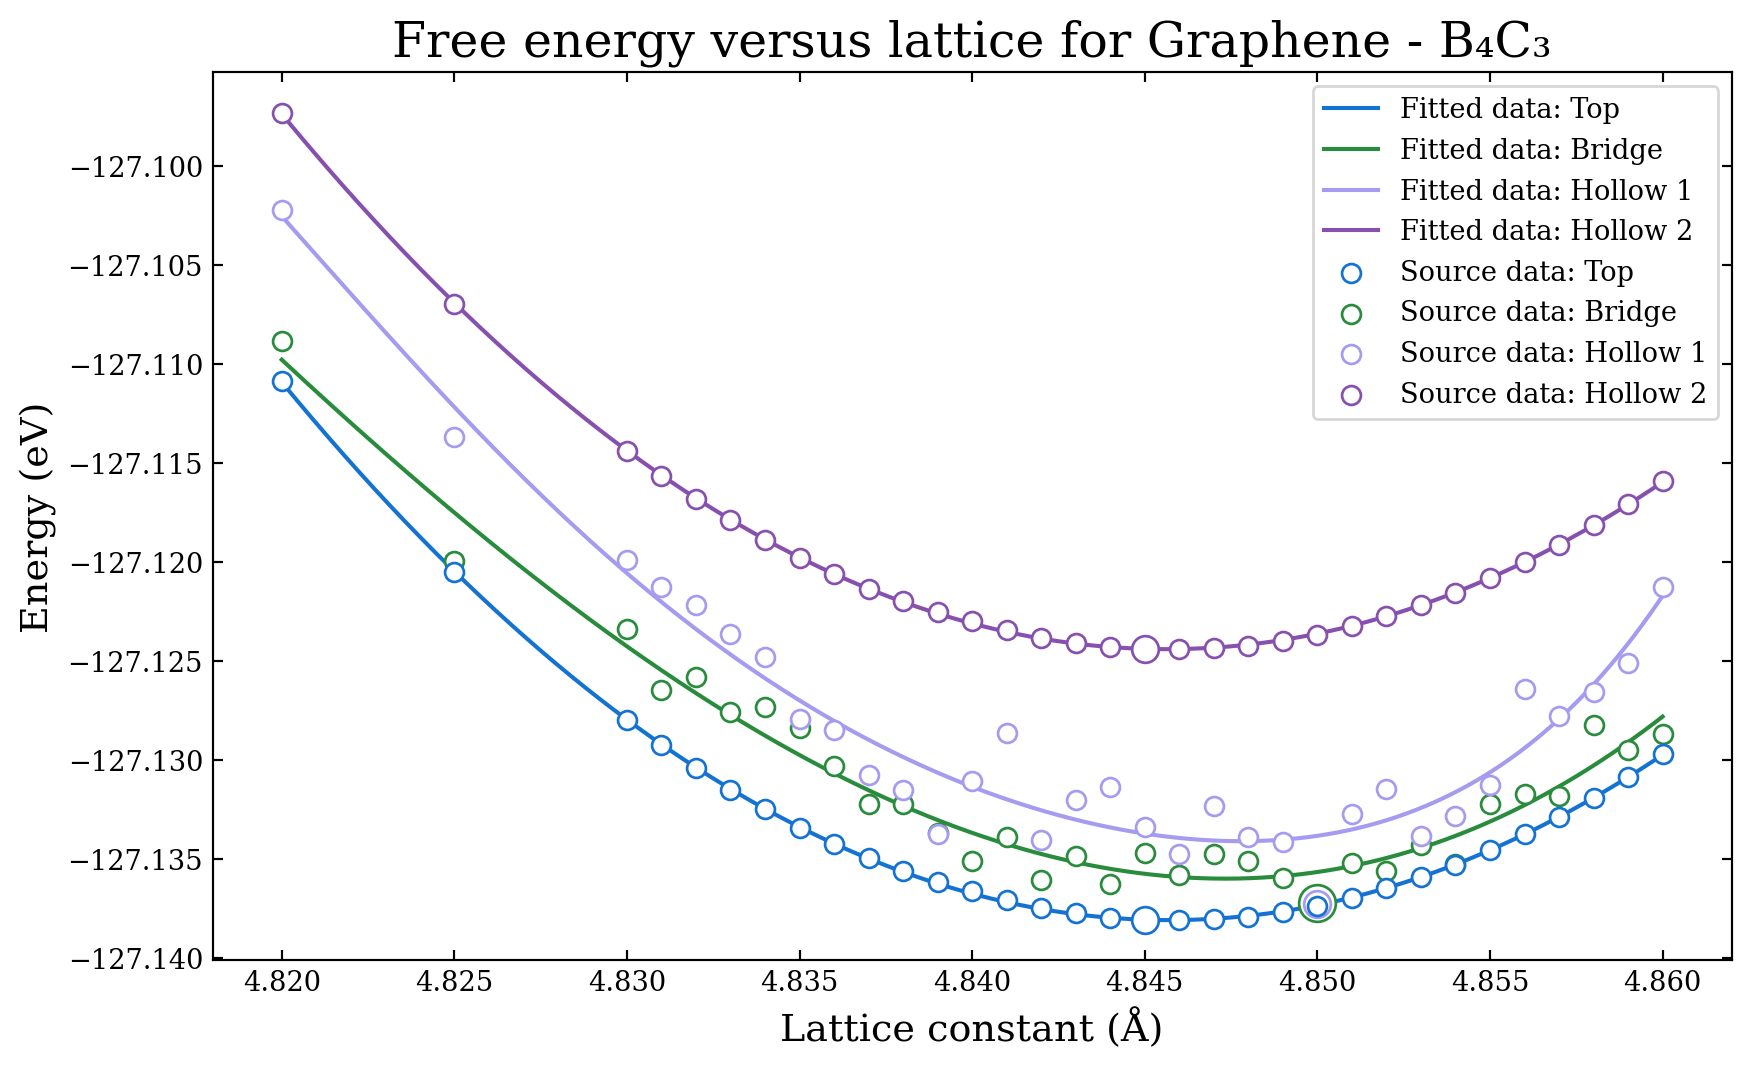

In [6]:
#### Graphene - B4C3

## Read data functions
import numpy as np
from Store.lattice_extracting import read_lattice_distance,  read_lattice_distance_select
from Store.lattice_selecting import lattice_select
from Store.filter_segment import filter_segment

Matter = "Graphene - B₄C₃"

## Lattice range
lattice_start = 4.82
lattice_end = 4.86

## Source data
# Top
lattice_Top_source, distance_Top_source, energy_Top_source = read_lattice_distance("0_Lattice_Twin_Lattice/C1_Graphene-B4C3_Top/lattice.dat")
# Bridge
lattice_Bridge_source, distance_Bridge_source, energy_Bridge_source = read_lattice_distance("0_Lattice_Twin_Lattice/C2_Graphene-B4C3_Bridge/lattice.dat")
# Hollow 1
lattice_Hollow_1_source, distance_Hollow_1_source, energy_Hollow_1_source = read_lattice_distance("0_Lattice_Twin_Lattice/C3_Graphene-B4C3_Hollow_1/lattice.dat")
# Hollow 2
lattice_Hollow_2_source, distance_Hollow_2_source, energy_Hollow_2_source = read_lattice_distance("0_Lattice_Twin_Lattice/C4_Graphene-B4C3_Hollow_2/lattice.dat")

## Discretized source data
divisor = 1
# Top
lattice_Top_dis, distance_Top_dis, energy_Top_dis = read_lattice_distance_select("0_Lattice_Twin_Lattice/C1_Graphene-B4C3_Top/lattice.dat",1000,divisor)
# Bridge
lattice_Bridge_dis, distance_Bridge_dis, energy_Bridge_dis = read_lattice_distance_select("0_Lattice_Twin_Lattice/C2_Graphene-B4C3_Bridge/lattice.dat",1000,divisor)
# Hollow 1
lattice_Hollow_1_dis, distance_Hollow_1_dis, energy_Hollow_1_dis = read_lattice_distance_select("0_Lattice_Twin_Lattice/C3_Graphene-B4C3_Hollow_1/lattice.dat",1000,divisor)
# Hollow 2
lattice_Hollow_2_dis, distance_Hollow_2_dis, energy_Hollow_2_dis = read_lattice_distance_select("0_Lattice_Twin_Lattice/C4_Graphene-B4C3_Hollow_2/lattice.dat",1000,divisor)

## Segment select
lattice_Top, distance_Top, energy_Top = filter_segment(lattice_Top_dis, distance_Top_dis, energy_Top_dis, lattice_start, lattice_end)
lattice_Bridge, distance_Bridge, energy_Bridge = filter_segment(lattice_Bridge_dis, distance_Bridge_dis, energy_Bridge_dis, lattice_start, lattice_end)
lattice_Hollow_1, distance_Hollow_1, energy_Hollow_1 = filter_segment(lattice_Hollow_1_dis, distance_Hollow_1_dis, energy_Hollow_1_dis, lattice_start, lattice_end)
lattice_Hollow_2, distance_Hollow_2, energy_Hollow_2 = filter_segment(lattice_Hollow_2_dis, distance_Hollow_2_dis, energy_Hollow_2_dis, lattice_start, lattice_end)
# Lattice range
lattice_range = max(max(lattice_Top), max(lattice_Bridge), max(lattice_Hollow_1), max(lattice_Hollow_2))-min(min(lattice_Top), min(lattice_Bridge), min(lattice_Hollow_1), min(lattice_Hollow_2))
# Energy range
energy_max = max(max(energy_Top), max(energy_Bridge), max(energy_Hollow_1), max(energy_Hollow_2))
energy_min = min(min(energy_Top), min(energy_Bridge), min(energy_Hollow_1), min(energy_Hollow_2))
energy_range = energy_max - energy_min

## Fit curve
# Top
p_Top = np.polyfit(lattice_Top, energy_Top, 3)
f_Top = np.poly1d(p_Top)
lattice_Top_fitted = np.linspace(min(lattice_Top), max(lattice_Top), num=1000, endpoint=True)
energy_Top_fitted = f_Top(lattice_Top_fitted)
# Bridge
p_Bridge = np.polyfit(lattice_Bridge, energy_Bridge, 3)
f_Bridge  = np.poly1d(p_Bridge)
lattice_Bridge_fitted = np.linspace(min(lattice_Bridge), max(lattice_Bridge), num=1000, endpoint=True)
energy_Bridge_fitted = f_Bridge(lattice_Bridge_fitted)
# Hollow 1
p_Hollow_1 = np.polyfit(lattice_Hollow_1, energy_Hollow_1, 12)
f_Hollow_1  = np.poly1d(p_Hollow_1)
lattice_Hollow_1_fitted = np.linspace(min(lattice_Hollow_1), max(lattice_Hollow_1), num=1000, endpoint=True)
energy_Hollow_1_fitted = f_Hollow_1(lattice_Hollow_1_fitted)
# Hollow 2
p_Hollow_2 = np.polyfit(lattice_Hollow_2, energy_Hollow_2, 3)
f_Hollow_2  = np.poly1d(p_Hollow_2)
lattice_Hollow_2_fitted = np.linspace(min(lattice_Hollow_2), max(lattice_Hollow_2), num=1000, endpoint=True)
energy_Hollow_2_fitted = f_Hollow_2(lattice_Hollow_2_fitted)

## Extrema point of source data
# Top
energy_Top_min = np.min(energy_Top_source)
lattice_Top_min = lattice_Top_source[np.argmin(energy_Top_source)]
# Bridge
energy_Bridge_min = np.min(energy_Bridge_source)
lattice_Bridge_min = lattice_Bridge_source[np.argmin(energy_Bridge_source)]
# Hollow_1
energy_Hollow_1_min = np.min(energy_Hollow_1_source)
lattice_Hollow_1_min = lattice_Hollow_1_source[np.argmin(energy_Hollow_1_source)]
# Hollow_2
energy_Hollow_2_min = np.min(energy_Hollow_2_source)
lattice_Hollow_2_min = lattice_Hollow_2_source[np.argmin(energy_Hollow_2_source)]

## Extrema point of fitted data
# Top
f_Top_prime = f_Top.deriv()
roots_Top = f_Top_prime.r
fitted_lattice_Top_extrema = roots_Top[(roots_Top >= min(lattice_Top)) & (roots_Top <= max(lattice_Top))]
fitted_energy_Top_extrema = f_Top(fitted_lattice_Top_extrema)
fitted_energy_Top_min = np.min(fitted_energy_Top_extrema)
fitted_lattice_Top_min = fitted_lattice_Top_extrema[np.argmin(fitted_energy_Top_min)]
# Bridge
f_Bridge_prime = f_Bridge.deriv()
roots_Bridge = f_Bridge_prime.r
fitted_lattice_Bridge_extrema = roots_Bridge[(roots_Bridge >= min(lattice_Bridge)) & (roots_Bridge <= max(lattice_Bridge))]
fitted_energy_Bridge_extrema = f_Bridge(fitted_lattice_Bridge_extrema)
fitted_energy_Bridge_min = np.min(fitted_energy_Bridge_extrema)
fitted_lattice_Bridge_min = fitted_lattice_Bridge_extrema[np.argmin(fitted_energy_Bridge_min)]
# Hollow 1
f_Hollow_1_prime = f_Hollow_1.deriv()
roots_Hollow_1 = f_Hollow_1_prime.r
fitted_lattice_Hollow_1_extrema = roots_Hollow_1[(roots_Hollow_1 >= min(lattice_Hollow_1)) & (roots_Hollow_1 <= max(lattice_Hollow_1))]
fitted_energy_Hollow_1_extrema = f_Hollow_1(fitted_lattice_Hollow_1_extrema)
fitted_energy_Hollow_1_min = np.min(fitted_energy_Hollow_1_extrema)
fitted_lattice_Hollow_1_min = fitted_lattice_Hollow_1_extrema[np.argmin(fitted_energy_Hollow_1_min)]

# Hollow 2
f_Hollow_2_prime = f_Hollow_2.deriv()
roots_Hollow_2 = f_Hollow_2_prime.r
fitted_lattice_Hollow_2_extrema = roots_Hollow_2[(roots_Hollow_2 >= min(lattice_Hollow_2)) & (roots_Hollow_2 <= max(lattice_Hollow_2))]
fitted_energy_Hollow_2_extrema = f_Hollow_2(fitted_lattice_Hollow_2_extrema)
fitted_energy_Hollow_2_min = np.min(fitted_energy_Hollow_2_extrema)
fitted_lattice_Hollow_2_min = fitted_lattice_Hollow_2_extrema[np.argmin(fitted_energy_Hollow_2_min)]

print(f"Fitted extrema lattice of Top: {np.float(fitted_lattice_Top_min)}(Å), the corresponding energy is {np.float(fitted_energy_Top_min)}(eV).")
print(f"Fitted extrema lattice of Bridge: {np.float(fitted_lattice_Bridge_min)}(Å), the corresponding energy is {np.float(fitted_energy_Bridge_min)}(eV).")
print(f"Fitted extrema lattice of Hollow 1: {np.float(fitted_lattice_Hollow_1_min)}(Å), the corresponding energy is {np.float(fitted_energy_Hollow_1_min)}(eV).")
print(f"Fitted extrema lattice of Hollow 2: {np.float(fitted_lattice_Hollow_2_min)}(Å), the corresponding energy is {np.float(fitted_energy_Hollow_2_min)}(eV).")

## Plot
import matplotlib.pyplot as plt

plt.figure(dpi=196, figsize=(10,6))
params = {"text.usetex": False, "font.family": "serif", "mathtext.fontset": "cm",
          "axes.titlesize": 18, "axes.labelsize": 14, "figure.facecolor": "w"}
plt.rcParams.update(params)
plt.tick_params(direction="in", which="both", top=True, right=True, bottom=True, left=True)
plt.title(f"Free energy versus lattice for {Matter}"); plt.xlabel(r"Lattice constant (Å)"); plt.ylabel(r"Energy (eV)")

# Source data: Top
plt.scatter(lattice_Top, energy_Top, s=48, facecolors="#FFFFFF", edgecolors="#1473D2", label="Source data: Top", zorder=3)
plt.scatter(lattice_Top_min, energy_Top_min, s=96, facecolors="#FFFFFF", edgecolors="#1473D2", zorder=4)
# Source data: Bridge
plt.scatter(lattice_Bridge, energy_Bridge, s=48, facecolors="#FFFFFF", edgecolors="#288C3C", label="Source data: Bridge", zorder=2)
plt.scatter(lattice_Bridge_min, energy_Bridge_min, s=182, facecolors="#FFFFFF", edgecolors="#288C3C", zorder=2)
# Source data: Hollow 1
plt.scatter(lattice_Hollow_1, energy_Hollow_1, s=48, facecolors="#FFFFFF", edgecolors="#A59BF0", label="Source data: Hollow 1", zorder=2)
plt.scatter(lattice_Hollow_1_min, energy_Hollow_1_min, s=96, facecolors="#FFFFFF", edgecolors="#A59BF0", zorder=2)
# Source data: Hollow 2
plt.scatter(lattice_Hollow_2, energy_Hollow_2, s=48, facecolors="#FFFFFF", edgecolors="#8750AF", label="Source data: Hollow 2", zorder=2)
plt.scatter(lattice_Hollow_2_min, energy_Hollow_2_min, s=96, facecolors="#FFFFFF", edgecolors="#8750AF", zorder=2)

# Fitted data: top
plt.plot(lattice_Top_fitted, energy_Top_fitted, color="#1473D2", label="Fitted data: Top", zorder=1)
# Fitted data: Bridge
plt.plot(lattice_Bridge_fitted, energy_Bridge_fitted, color="#288C3C", label="Fitted data: Bridge", zorder=1)
# Fitted data: Hollow 1
plt.plot(lattice_Hollow_1_fitted, energy_Hollow_1_fitted, color="#A59BF0", label="Fitted data: Hollow 1", zorder=1)
# Fitted data: Hollow 2
plt.plot(lattice_Hollow_2_fitted, energy_Hollow_2_fitted, color="#8750AF", label="Fitted data: Hollow 2", zorder=1)

plt.ylim(energy_min-energy_range*0.05,energy_max+energy_range*0.05)
plt.legend(loc="upper right")